In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muratkokludataset/pumpkin-seeds-dataset/Pumpkin_Seeds_Dataset/Pumpkin_Seeds_Dataset.arff
/kaggle/input/datasets/muratkokludataset/pumpkin-seeds-dataset/Pumpkin_Seeds_Dataset/Pumpkin_Seeds_Dataset.xlsx
/kaggle/input/datasets/muratkokludataset/pumpkin-seeds-dataset/Pumpkin_Seeds_Dataset/Pumpkin_Seeds_Dataset_Citation_Request.txt


In [2]:
data=pd.read_excel("/kaggle/input/datasets/muratkokludataset/pumpkin-seeds-dataset/Pumpkin_Seeds_Dataset/Pumpkin_Seeds_Dataset.xlsx")

In [3]:
y=data["Class"]
x=data.drop("Class",axis=1)

In [4]:
x.isnull().sum()

Area                 0
Perimeter            0
Major_Axis_Length    0
Minor_Axis_Length    0
Convex_Area          0
Equiv_Diameter       0
Eccentricity         0
Solidity             0
Extent               0
Roundness            0
Aspect_Ration        0
Compactness          0
dtype: int64

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
def get_score(n_estimators):
    # Pipeline tanımla
    
    my_pipeline = Pipeline(steps=[
        ('model', RandomForestClassifier(n_estimators=n_estimators, random_state=0))
    ])
    
    # Cross-validation skorlarını al
    scores = cross_val_score(my_pipeline, x, y,
                                  cv=5,
                                  scoring='accuracy')
    
    # Ortalama MAE döndür
    return scores.mean()

In [6]:
results={}
for i in range (1,20):
    i=i*50
    results[i]=get_score(i)


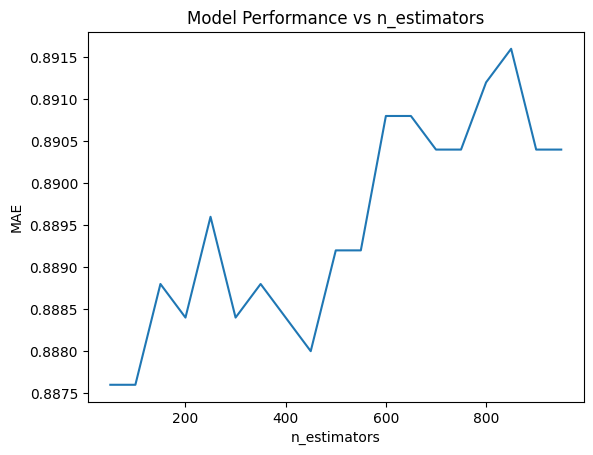

In [7]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(results.keys(), results.values())
plt.xlabel("n_estimators")
plt.ylabel("MAE")
plt.title("Model Performance vs n_estimators")
plt.show()

In [8]:
model=RandomForestClassifier(n_estimators=100,random_state=0)